# Financial Trading with Python, 2nd Edition

Cordell L. Tanny, CFA, FRM, FDP

Chapter 13: Algorithmic Trading Strategies

Notebook 13.5: Regime Rotation with the Box Manufacturing Index

Version 1.0

Last revised: June 21, 2026

**A rotation signal built from a revised economic series, and why point-in-time data separates a real backtest from a fiction.**

Before running anything, go to File and select Save a copy in Drive so you keep your own editable version.

## 1.0 Introduction

In the previous notebook we built a rotation strategy whose canary was price momentum. A canary is a single indicator we watch to decide whether the broad market is favorable enough to hold offensive assets, or risky enough that we should rotate into defensive ones. Price momentum has one convenient property: prices are never revised. The closing price of an asset on a past date is the same number today as it was back then.

This notebook uses a different kind of canary, and that difference is the whole lesson. The signal comes from a macroeconomic series, the Producer Price Index for corrugated and solid fiber box manufacturing, published by the U.S. Bureau of Labor Statistics and distributed through FRED. The strategy is from a December 2025 research paper by David Belobrad and Radovan Vojtko, who study whether the price of the boxes that goods ship in carries useful information about consumer-driven sectors of the economy. Their thesis is that packaging demand rises and falls with the flow of goods, so the box PPI may serve as an early read on real economic activity.

The trading rule itself is mechanical. We compare the box PPI against its own moving average across six windows ranging from three months to thirty-six months. When the index sits below a given window's average, that window votes to hold the offensive asset, Consumer Discretionary (XLY). When the index sits at or above the average, that window votes defensive. The fraction of windows voting offensive sets the allocation to XLY, and the remainder is split equally across a defensive mix of Utilities, Health Care, and Consumer Staples (XLU, XLV, XLP). Because six windows can each vote either way, the signal is graded across seven levels rather than a simple on or off, and we rebalance once a month.

The complication, and the reason this notebook exists, is that macroeconomic data gets revised. The box PPI number first published for a given month is not the number you see in FRED today. The agency restates it as more survey responses arrive. If we build a backtest using today's revised values, we are making past decisions with numbers that did not exist on the decision date. That is a form of lookahead bias, and it is invisible unless you go looking for it. To recover the history the strategy could actually have traded on, we pull the first published value of each month from ALFRED, the archival companion to FRED, and compare it against the revised series. This point-in-time question is not raised in the original paper; it is the part of the work that this notebook contributes.

We will cover:

- The economic thesis behind the box PPI as a signal, drawn from the original research
- Pulling price data for the four sector ETFs with yfinance
- Pulling the box PPI two ways, the latest revised series and the first-release series from ALFRED, and measuring the gap between them
- Building the six moving-average ensemble that grades the signal from fully defensive to fully offensive
- Testing the canary as a classifier before we trust it in a backtest: confusion matrix, classification report, a conditional payoff across all seven vote levels, a crisis event study, and a whipsaw diagnostic
- Running the scored backtest through our vectorbt harness, then knocking the canary out to confirm the signal was doing the work

## 2.0 Setup and configuration

Every value the strategy depends on lives in one place, the configuration block below, so that changing a date range or swapping a ticker is a single edit rather than a hunt through the notebook. This is the question this section answers: what are the fixed choices that define the strategy, and where do we change them.

A few of these choices carry weight worth explaining now. The six moving-average windows, from three months to thirty-six months, are the ensemble taken directly from the source research. The asset universe puts Consumer Discretionary on the offensive side and an equal-weight mix of Utilities, Health Care, and Consumer Staples on the defensive side, again following the paper's final design. The start date is set to December 1998 because that is when the four sector ETFs began trading, and the strategy cannot hold an asset before it exists.

One item is not optional. The box PPI is pulled from FRED and its archival companion ALFRED, and both require a free API key. You request a key from the Federal Reserve Bank of St. Louis, then store it in Colab under the Secrets tab using the exact name FRED_API_KEY. The cell below reads it from there. If you have not set this up, the data section later will fail, so it is worth doing now before going further. After running the cell, look for the confirmation that the key was found and the configuration printed back to you.

In [12]:
# =============================================================================
# CONFIGURATION
# =============================================================================
# All fixed choices for the strategy live here. Change a value once in this
# block and it propagates everywhere downstream.

!pip install vectorbt==0.28.5 pandas==2.2.2 numpy==2.0.2 yfinance -q fredapi

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from fredapi import Fred
from google.colab import userdata
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# --- FRED / ALFRED API key -------------------------------------------------
# The box PPI series is pulled from FRED, and its point-in-time vintages come
# from ALFRED. Both run through the same fredapi client, which needs a free
# API key. Request one at https://fred.stlouisfed.org/docs/api/api_key.html
# then store it in Colab under the key icon (Secrets) with the EXACT name
# FRED_API_KEY. We read it here rather than pasting the key into the notebook,
# so the key never gets saved into the file or shared by accident.
FRED_API_KEY = userdata.get('FRED_API_KEY')

# --- The box PPI series ------------------------------------------------------
# PCU3222113222110 is the BLS Producer Price Index for corrugated and solid
# fiber box manufacturing. This single series is the canary that drives the
# entire strategy.
FRED_SERIES_ID = 'PCU3222113222110'

# --- Moving-average ensemble -------------------------------------------------
# Six lookback windows in MONTHS. Each window compares the current PPI level
# against its own moving average and casts one vote. The windows run from
# short (3 months, reacts quickly) to long (36 months, reacts slowly), so the
# ensemble blends fast and slow reads of the same series. Taken directly from
# the source research.
MA_WINDOWS = [3, 6, 9, 12, 24, 36]

# --- Asset universe ----------------------------------------------------------
# Offensive: Consumer Discretionary. Held when the ensemble leans offensive.
# Defensive: an equal-weight mix of Utilities, Health Care, Consumer Staples,
# held in the proportion of windows voting defensive.
OFFENSIVE_TICKER = 'XLY'
DEFENSIVE_TICKERS = ['XLU', 'XLV', 'XLP']
ALL_TICKERS = [OFFENSIVE_TICKER] + DEFENSIVE_TICKERS

# --- Broad-market reference for the signal test ------------------------------
# The classifier test later asks whether the canary predicts down months in
# the broad market. SPY is the yardstick for "the market" in that test. It is
# NOT one of the traded assets; it is only the outcome we score the signal
# against.
MARKET_TICKER = 'SPY'

# --- Date range --------------------------------------------------------------
# Start at the sector-ETF inception (December 1998). The strategy cannot hold
# an ETF before it traded, and the 36-month warmup on the longest window means
# the first live signal arrives about three years after this date regardless.
START_DATE = '1998-12-01'
END_DATE = '2026-05-31'

# --- Publication lag ---------------------------------------------------------
# The box PPI is released about a month after the month it describes, and not
# on a fixed schedule. The source paper implements every decision with a
# one-month delay for this reason. We carry the same one-month lag so the
# strategy only ever acts on a number it could actually have seen.
PUBLICATION_LAG_MONTHS = 1

# --- Quick confirmation ------------------------------------------------------
# Fail loudly and early if the key is missing, rather than deep in the data
# pull where the error would be harder to read.
if not FRED_API_KEY:
    raise ValueError(
        "FRED_API_KEY not found in Colab Secrets. Add it under the key icon "
        "in the left sidebar with the exact name FRED_API_KEY, then re-run."
    )

print("Configuration loaded.")
print(f"  Box PPI series:     {FRED_SERIES_ID}")
print(f"  MA windows (months): {MA_WINDOWS}")
print(f"  Offensive:          {OFFENSIVE_TICKER}")
print(f"  Defensive:          {DEFENSIVE_TICKERS}")
print(f"  Market reference:   {MARKET_TICKER}")
print(f"  Date range:         {START_DATE} to {END_DATE}")
print(f"  Publication lag:    {PUBLICATION_LAG_MONTHS} month(s)")
print(f"  FRED API key:       found")

Configuration loaded.
  Box PPI series:     PCU3222113222110
  MA windows (months): [3, 6, 9, 12, 24, 36]
  Offensive:          XLY
  Defensive:          ['XLU', 'XLV', 'XLP']
  Market reference:   SPY
  Date range:         1998-12-01 to 2026-05-31
  Publication lag:    1 month(s)
  FRED API key:       found


The output confirms the two things that matter before going further. The FRED API key was found in Colab Secrets, shown by the "found" line at the bottom, and every fixed choice printed back exactly as set: the box PPI series, the six moving-average windows, the offensive and defensive tickers, the SPY reference used only for scoring the signal, the date range, and the one-month publication lag.

If your run instead stopped with an error about the key not being found, the key is either missing from Secrets or stored under a different name. Open the key icon in the left sidebar, confirm the entry is named exactly FRED_API_KEY with no extra spaces, and that notebook access is toggled on for it, then run the cell again.

With the configuration in place, we can pull the data the strategy needs: the four sector ETF prices, the broad-market reference, and the box PPI itself in its two forms.

## 3.0 Pulling the data

The strategy needs two kinds of data: the prices of the assets it trades, and the box PPI that drives the decisions. This section pulls the prices first, because they are the simple part, and then turns to the PPI, where the point-in-time question lives.

For prices we pull the four sector ETFs plus the SPY reference from yfinance, using adjusted prices so that dividends and splits are already folded in. Adjusted prices are what a backtest should use, because they reflect the total return an investor actually received rather than just the quoted price. The question this part answers is narrow: do we have clean, complete daily price histories for all five tickers over the test window. Look in the output for the date each series starts, since the sector ETFs began trading in late 1998 and that start date sets the earliest the strategy could ever run.

In [13]:
# =============================================================================
# 3.1 ETF prices from yfinance
# =============================================================================
# Pull adjusted daily prices for the four traded ETFs plus the SPY reference.
# auto_adjust=True means yfinance folds dividends and splits into the price,
# so the "Close" column is already a total-return-adjusted price. That is what
# a backtest needs: it reflects what an investor actually earned, not just the
# headline quote.

# We pull the traded tickers and the SPY reference together in one request.
price_tickers = ALL_TICKERS + [MARKET_TICKER]

# auto_adjust=True: adjusted prices (dividends/splits already applied).
# progress=False: keep the notebook output clean.
df_raw = yf.download(
    price_tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)

# yfinance returns a multi-level column index when downloading several tickers.
# We want just the adjusted close, which under auto_adjust=True is "Close".
df_prices = df_raw['Close'].copy()

# Reorder columns to a known, fixed order. yfinance returns them alphabetically,
# and we never want to rely on that ordering downstream when weights and prices
# have to line up. Being explicit here prevents a whole class of silent bugs.
df_prices = df_prices[price_tickers]

# Report what we got: the start date of each series matters because the
# strategy cannot hold an ETF before it existed.
print("Adjusted daily prices pulled from yfinance.")
print(f"  Shape: {df_prices.shape[0]} rows, {df_prices.shape[1]} columns")
print(f"  Full date range: {df_prices.index.min().date()} to {df_prices.index.max().date()}")
print("\n  First valid date per ticker:")
for t in price_tickers:
    first = df_prices[t].first_valid_index()
    print(f"    {t}: {first.date()}")

print("\n  Tail (last 3 rows):")
print(df_prices.tail(3).round(2).to_string())

Adjusted daily prices pulled from yfinance.
  Shape: 6915 rows, 5 columns
  Full date range: 1998-12-01 to 2026-05-29

  First valid date per ticker:
    XLY: 1998-12-22
    XLU: 1998-12-22
    XLV: 1998-12-22
    XLP: 1998-12-22
    SPY: 1998-12-01

  Tail (last 3 rows):
Ticker         XLY    XLU     XLV    XLP     SPY
Date                                            
2026-05-27  121.55  45.14  148.79  84.58  748.53
2026-05-28  122.06  44.63  150.88  84.43  752.66
2026-05-29  120.87  44.42  149.47  82.91  754.54


The pull came back complete. All four sector ETFs begin on the same day, December 22, 1998, which is their shared inception, and SPY runs from the start of the window. There are no gaps to patch and the recent prices look sensible, so the price side needs no further cleaning.

That shared 1998 start date matters for one reason. The strategy's longest moving-average window is thirty-six months, so the signal cannot produce its first vote until about three years of PPI history has accumulated. The ETFs existing from late 1998 means the price data will always be ready before the signal is, and the binding constraint on when the strategy can start is the PPI warmup, not the prices. We will see exactly where that first live signal lands once the PPI is in hand.

With prices settled, we turn to the box PPI, where the data is not as simple as it looks.

### 3.2 The box PPI, two ways

Here is the part that makes this strategy different from a price-momentum rotation. The box PPI is a survey-based statistic, and the Bureau of Labor Statistics revises it after first publication as late survey responses arrive. The number you download today for, say, March 2015, is not necessarily the number that was on the screen in mid-2015 when a trader would have acted on it.

This creates a trap. If we build the signal from today's fully revised series and then run a backtest, the strategy is quietly making past decisions using information that did not exist yet. The revisions leak future knowledge backward into the past. The effect is usually small for any single month, but it is a real form of lookahead bias, and the whole point of a careful backtest is to use only what was knowable at the time.

To handle this properly we pull the series twice. The first pull, with get_series, returns the latest revised values, which is what almost everyone uses and what the trap is built on. The second pull, with get_series_first_release, returns the value as it was first published for each month, which is the closest record we have of what a trader could actually have seen. We then line the two up and measure how far apart they are. The question this section answers is whether the revisions are large enough to matter for this particular series, and we will let the numbers decide rather than assume.

A note on method. We use the first published value rather than asking for the exact snapshot as of each historical decision date. For a monthly series that arrives about a month after the period it describes, the first release is a clean and defensible stand-in for what was knowable, and it lines up with the one-month delay the source paper already applies.

In [14]:
# =============================================================================
# 3.2 Pull the box PPI two ways: latest-revised vs first-release
# =============================================================================
# The box PPI is revised after first publication. To avoid building the signal
# on numbers that did not exist on the decision date, we pull the series twice
# and compare.

# One client, used for both pulls. The key was loaded in the config cell.
fred = Fred(api_key=FRED_API_KEY)

# --- Pull 1: latest revised series ------------------------------------------
# get_series returns today's fully revised history. This is what most people
# use, and it is exactly the version that can smuggle revised (future) values
# into a backtest of the past.
ppi_revised = fred.get_series(
    FRED_SERIES_ID,
    observation_start=START_DATE,
    observation_end=END_DATE,
)
ppi_revised.name = 'ppi_revised'

# --- Pull 2: first-release series -------------------------------------------
# get_series_first_release returns, for each observation month, the value as it
# was FIRST published, before any later revision. This is the point-in-time
# record: the closest stand-in for what was actually knowable at the time.
ppi_first = fred.get_series_first_release(FRED_SERIES_ID)
ppi_first.name = 'ppi_first'

# The first-release pull does not take a date window, so trim it to ours.
ppi_first = ppi_first[
    (ppi_first.index >= pd.to_datetime(START_DATE)) &
    (ppi_first.index <= pd.to_datetime(END_DATE))
]

# --- Align the two on a common monthly index --------------------------------
# Put both versions side by side so we can compare them month for month.
df_ppi = pd.concat([ppi_revised, ppi_first], axis=1)

# Report basic shape and coverage of each version.
print("Box PPI pulled in two versions.")
print(f"  Revised series:       {ppi_revised.dropna().shape[0]} monthly values")
print(f"    range: {ppi_revised.dropna().index.min().date()} to {ppi_revised.dropna().index.max().date()}")
print(f"  First-release series: {ppi_first.dropna().shape[0]} monthly values")
print(f"    range: {ppi_first.dropna().index.min().date()} to {ppi_first.dropna().index.max().date()}")

# Where both versions exist, measure the revision: revised minus first-release.
both = df_ppi.dropna()
revision = both['ppi_revised'] - both['ppi_first']
revision_pct = revision / both['ppi_first'] * 100

print(f"\n  Months where both versions exist: {both.shape[0]}")
print(f"  Revision (revised minus first release), index points:")
print(f"    mean: {revision.mean():+.3f}   min: {revision.min():+.3f}   max: {revision.max():+.3f}")
print(f"  Revision as percent of first release:")
print(f"    mean: {revision_pct.mean():+.3f}%   min: {revision_pct.min():+.3f}%   max: {revision_pct.max():+.3f}%")
print(f"  Months where the two differ at all: {(revision.abs() > 1e-9).sum()} of {both.shape[0]}")

print(f"\n  Most recent 6 months, side by side:")
print(df_ppi.dropna().tail(6).round(3).to_string())

Box PPI pulled in two versions.
  Revised series:       330 monthly values
    range: 1998-12-01 to 2026-05-01
  First-release series: 330 monthly values
    range: 1998-12-01 to 2026-05-01

  Months where both versions exist: 330
  Revision (revised minus first release), index points:
    mean: -0.061   min: -3.077   max: +4.281
  Revision as percent of first release:
    mean: -0.016%   min: -0.703%   max: +1.028%
  Months where the two differ at all: 130 of 330

  Most recent 6 months, side by side:
            ppi_revised ppi_first
2025-12-01      466.404   466.455
2026-01-01      466.506   466.404
2026-02-01      466.705   466.778
2026-03-01      465.714   465.751
2026-04-01      465.179   465.181
2026-05-01      479.997   479.997


The comparison gives a clear and slightly reassuring answer. Both versions cover the same 330 months, and the two disagree in 130 of them, so revision is not a rare event for this series; it happens routinely, in roughly four months out of ten. What saves us is the size of those revisions. The average gap between the revised and first-release value is about two-hundredths of one percent, and even the largest single revision in the whole history is around one percent of the index level. In index points, the worst case is a swing of about four points on a level that sits in the hundreds.

The recent six-month table shows the pattern in miniature. Most months match to the third decimal or differ by a few hundredths, and the newest month, May 2026, is identical in both versions because it has not yet had time to be revised.

So what does this mean for the strategy. The signal does not read the PPI level directly; it compares the level to its own moving average and only cares which side of the average the level sits on. A revision of a fraction of a percent will almost never flip a value from one side of a moving average to the other, so for this particular series the revisions are very unlikely to change the trading decisions. That is a genuine finding, not a disappointment. The lesson of this section is the method, not the magnitude: you pull the first-release series, you measure the gap, and you let the data tell you whether revisions matter before you trust a backtest. For the box PPI they turn out to be small. For other macro series, gross domestic product being the classic example, first releases can be revised by amounts large enough to reverse a signal entirely, and the same check would then save you from a backtest built on knowledge you did not have.

To stay on the side of using only what was knowable, we build the strategy on the first-release series from here forward, and keep the revised series only as the comparison we just made.

## 4.0 Building the signal

The signal turns one PPI series into a monthly allocation. The recipe has three steps, and the order matters.

First, we apply the publication lag. The box PPI for a given month is not released until about a month later, so a value dated March is only knowable from April onward. We shift the series forward by one month so that each value sits on the date it could first have been used, never earlier. This is the single most important guard against lookahead bias in the whole notebook, and it has to happen before anything else touches the series.

Second, we compute the six moving averages on the lagged series, one for each window from three to thirty-six months. Because the lag was applied first, every average is built only from values that were already public at that point.

Third, we tally the vote. At each month, each of the six windows compares the current PPI level to its own moving average. A level below the average is a vote for the offensive asset, XLY, on the logic from the source paper that a below-trend reading is the entry condition. A level at or above the average is a vote for the defensive mix. The offensive allocation is simply the fraction of windows voting offensive, so it steps through seven possible values from zero to one, and the defensive remainder is split equally across XLU, XLV, and XLP.

After running the cell, look at the spread of the offensive fraction over time and the date of the first complete signal, which should land about three years after the PPI history begins because the thirty-six-month window needs that long to warm up.

In [15]:
# =============================================================================
# 4.0 Build the graded signal from the first-release PPI
# =============================================================================
# Three steps, in this order: (1) apply the one-month publication lag, then
# (2) compute the six moving averages on the lagged series, then (3) tally the
# six-window vote into a graded offensive fraction.

# Work from the first-release series only. Cast to float: the ALFRED pull can
# come back as object dtype, which would make the rolling math unreliable.
ppi = df_ppi['ppi_first'].dropna().astype(float).copy()

# Make sure the index is a clean month-start datetime and sorted, so the
# shift and the rolling windows line up on a regular monthly grid.
ppi.index = pd.to_datetime(ppi.index)
ppi = ppi.sort_index()

# --- Step 1: publication lag -------------------------------------------------
# Shift forward by one month. After this, the value labeled (say) 2015-04 is
# the PPI for MARCH, now sitting on April because that is the first month it
# was knowable. Every later calculation uses only these lagged, knowable values.
ppi_lagged = ppi.shift(PUBLICATION_LAG_MONTHS)

# --- Step 2: the six moving averages ----------------------------------------
# One simple moving average per window, all computed on the lagged series.
df_sig = pd.DataFrame({'ppi': ppi_lagged})
for w in MA_WINDOWS:
    df_sig[f'ma_{w}'] = ppi_lagged.rolling(window=w, min_periods=w).mean()

# Drop the entire warmup now, before computing any votes. A row is in warmup if
# the lagged PPI is missing OR any one of the six moving averages is still NaN.
# Removing these rows here means everything downstream works on a frame where
# all six windows are fully formed, so no partial-warmup month can leak through.
ma_cols = [f'ma_{w}' for w in MA_WINDOWS]
df_sig = df_sig.dropna(subset=['ppi'] + ma_cols).copy()

# --- Step 3: tally the graded vote ------------------------------------------
# Every row now has all six MAs, so the votes are clean integers with no NaN.
# For each window: 1 (offensive) when the level is below its MA, else 0.
vote_cols = []
for w in MA_WINDOWS:
    col = f'vote_{w}'
    df_sig[col] = (df_sig['ppi'] < df_sig[f'ma_{w}']).astype(int)
    vote_cols.append(col)

# Offensive fraction: the mean of the six votes, stepping through 0, 1/6, ... 1.
df_sig['offensive_frac'] = df_sig[vote_cols].mean(axis=1)

# The offensive fraction. Using the votes' mean across the six windows gives
# the fraction directly. Rows still in warmup (any MA still NaN) yield NaN here
# and are dropped next.
df_sig['offensive_frac'] = df_sig[vote_cols].mean(axis=1)

# Drop warmup rows: keep only months where all six windows have a real vote.
df_sig = df_sig.dropna(subset=['offensive_frac']).copy()

# Report the shape of the finished signal.
print("Graded signal built from first-release PPI.")
print(f"  Signal months: {df_sig.shape[0]}")
print(f"  First complete signal: {df_sig.index.min().date()}")
print(f"  Last signal:           {df_sig.index.max().date()}")

# Show how often each of the seven offensive-fraction levels occurs.
print(f"\n  Distribution of the offensive fraction (share of months at each level):")
counts = df_sig['offensive_frac'].value_counts().sort_index()
for level, n in counts.items():
    print(f"    {level:.3f} ({int(round(level*6))}/6 offensive): {n:3d} months  ({n/len(df_sig)*100:4.1f}%)")

print(f"\n  Most recent 6 months of votes and fraction:")
show_cols = vote_cols + ['offensive_frac']
print(df_sig[show_cols].tail(6).to_string())

Graded signal built from first-release PPI.
  Signal months: 294
  First complete signal: 2001-12-01
  Last signal:           2026-05-01

  Distribution of the offensive fraction (share of months at each level):
    0.000 (0/6 offensive): 125 months  (42.5%)
    0.167 (1/6 offensive):  30 months  (10.2%)
    0.333 (2/6 offensive):  22 months  ( 7.5%)
    0.500 (3/6 offensive):  27 months  ( 9.2%)
    0.667 (4/6 offensive):  34 months  (11.6%)
    0.833 (5/6 offensive):  27 months  ( 9.2%)
    1.000 (6/6 offensive):  29 months  ( 9.9%)

  Most recent 6 months of votes and fraction:
            vote_3  vote_6  vote_9  vote_12  vote_24  vote_36  offensive_frac
2025-12-01       1       0       0        0        0        0        0.166667
2026-01-01       0       1       0        0        0        0        0.166667
2026-02-01       1       1       0        0        0        0        0.333333
2026-03-01       0       0       0        0        0        0        0.000000
2026-04-01       1    

The signal now starts where it should. The first complete reading lands in December 2001, three full years after the PPI history begins, because the thirty-six-month window needs that long to form, and dropping the warmup removed exactly those 36 months to leave 294 months of usable signal.

The distribution across the seven levels is worth pausing on, because it is lopsided in a way that shapes everything that follows. The most common state by far, almost 43 percent of all months, is zero out of six windows voting offensive, meaning the PPI sat at or above every one of its moving averages. The fully offensive state, six out of six, occurs about 10 percent of the time. The middle levels each cover somewhere between 7 and 12 percent. So the strategy spends a large share of its life fully defensive, occasionally goes fully offensive, and passes through the graded middle states the rest of the time.

That imbalance is not a flaw, but it is a warning for how we test the signal next. When one outcome dominates almost half the sample, a naive accuracy score can look impressive while telling us nothing, because a model that simply guessed the common state every time would already be right a large fraction of the time. We will keep that firmly in mind when we score the canary as a classifier, and it is the reason we look past raw accuracy to precision, recall, and the payoff in each state.

The recent six months show the signal climbing out of a fully defensive reading: the short windows turned offensive first, in the expected order, with the three and six month windows leading and the longer windows still defensive. That ordering, short windows flipping before long ones, is exactly what a blend of fast and slow signals should do.



## 5.0 Backtesting the strategy

We now turn the monthly signal into a set of portfolio weights and run it through the backtest harness. The strategy is the one from the source paper in its final form: the offensive fraction sets the allocation to Consumer Discretionary, and the remainder is split equally across the three defensive sectors, rebalanced once a month.

The harness expects what we call a sparse weights file. Each row is a rebalance date, the columns are the four traded tickers, and the values are the decimal weights we want to hold from that date until the next row. Because we rebalance every month, we write one row per signal month. The warmup is already gone, so every row has a complete, valid weight vector that sums to one.

This section answers the question the whole notebook has been building toward: once you account for trading costs, does rotating between Consumer Discretionary and a defensive sector mix on the box signal actually deliver a better risk and reward profile than simply holding the sectors. The paper reports improved Sharpe and Calmar with lower drawdowns, and we want to see whether our independent build, on point-in-time data and with costs applied, lands in the same place. After running the backtest, look at the risk-adjusted numbers and the drawdown rather than the headline return, because that is where this strategy makes its case.

In [16]:
# =============================================================================
# 5.1 Build the sparse weights file
# =============================================================================
# Turn each month's offensive fraction into a full weight vector across the
# four traded tickers, matching the allocation rule from the source research:
#   XLY            = offensive_frac
#   XLU, XLV, XLP  = (1 - offensive_frac) / 3 each
# One row per signal month (monthly rebalance), warmup already removed.

# Start from the finished signal. offensive_frac is the only column we need.
weights = pd.DataFrame(index=df_sig.index)

# Offensive leg: Consumer Discretionary takes the full offensive fraction.
weights[OFFENSIVE_TICKER] = df_sig['offensive_frac']

# Defensive leg: the remainder, split equally across the three defensive
# sectors. With three names, each gets one third of whatever is not offensive.
defensive_each = (1.0 - df_sig['offensive_frac']) / len(DEFENSIVE_TICKERS)
for t in DEFENSIVE_TICKERS:
    weights[t] = defensive_each

# Put columns in the fixed order we defined in config, never relying on the
# order they happened to be created in.
weights = weights[ALL_TICKERS]

# --- Sanity checks before we hand this to the harness -----------------------
# Every row must sum to 1.0 (fully invested, no leverage, no cash gap).
row_sums = weights.sum(axis=1)
assert np.allclose(row_sums, 1.0), \
    f"Weights do not sum to 1.0; min={row_sums.min()}, max={row_sums.max()}"

# No missing values anywhere: warmup was dropped, so this should hold.
assert not weights.isna().any().any(), "Weights contain NaN; warmup not fully removed."

# No negative weights: the fraction is bounded in [0, 1], so this should hold.
assert (weights >= 0).all().all(), "Negative weight found; check the fraction logic."

# Write the sparse weights file. The harness reads this back, so we save it with
# a date index and the bare ticker columns it expects.
weights_path = 'box_index_weights.csv'
weights.index.name = 'date'
weights.to_csv(weights_path, float_format='%.6f')

print("Sparse weights file written.")
print(f"  Path: {weights_path}")
print(f"  Rows (rebalance months): {weights.shape[0]}")
print(f"  Columns: {list(weights.columns)}")
print(f"  Date range: {weights.index.min().date()} to {weights.index.max().date()}")
print(f"  Row sums all 1.0: {np.allclose(weights.sum(axis=1), 1.0)}")
print(f"\n  First 3 rows:")
print(weights.head(3).round(4).to_string())
print(f"\n  Last 3 rows:")
print(weights.tail(3).round(4).to_string())

Sparse weights file written.
  Path: box_index_weights.csv
  Rows (rebalance months): 294
  Columns: ['XLY', 'XLU', 'XLV', 'XLP']
  Date range: 2001-12-01 to 2026-05-01
  Row sums all 1.0: True

  First 3 rows:
               XLY     XLU     XLV     XLP
date                                      
2001-12-01  0.8333  0.0556  0.0556  0.0556
2002-01-01  0.8333  0.0556  0.0556  0.0556
2002-02-01  0.8333  0.0556  0.0556  0.0556

  Last 3 rows:
               XLY     XLU     XLV     XLP
date                                      
2026-03-01  0.0000  0.3333  0.3333  0.3333
2026-04-01  0.5000  0.1667  0.1667  0.1667
2026-05-01  0.6667  0.1111  0.1111  0.1111


The weights file is built and every check passed: 294 monthly rows from December 2001 to May 2026, the four tickers in the fixed order the harness expects, and every row summing to one. The first rows sit fully offensive at the strategy's start, and the last rows show the recent climb out of a defensive reading, with Consumer Discretionary moving from zero in March up to two-thirds by May.

The dates need a careful word, because this notebook dates its rows differently from the other strategies in this chapter, and the difference is deliberate.

Think about one value moving through the system, the box PPI for December. The Bureau labels it with the first of December. The strategy treats that value as available one month later, on the first of January, which is the publication delay we built in earlier when we shifted the series forward by a month. So on the first trading day of January, the newest PPI value the strategy holds is December's, and it uses that value to compute the six moving averages and set the January allocation. The trade happens that same first trading day of January, at the close. In short, December's box PPI drives the trade made at the start of January.

That is why the rows are dated to the first of the month rather than the last. A row dated the first of January carries December's PPI and triggers a trade at the start of January. This follows the reference implementation of the strategy exactly, which stamps each PPI reading as available one month after its labelled date and trades from that point.

This is where the convention differs from the other chapter strategies, and it is worth understanding why. The momentum and allocation strategies elsewhere in the chapter build their signal from prices, and prices are known the moment the month closes, so those strategies can evaluate the signal at month-end and trade at that same month-end close. Their weight rows are dated to the last day of the month. This strategy cannot do that, because its signal comes from an economic release that is not published until after the month it describes. We cannot trade December's PPI at the December close, because in December that number does not exist yet. The earliest the strategy can act is the start of the next month, so the rows are dated to the first of the month, and the trade lands at the start of the month on the prior month's data.

One assumption is baked into this and should be stated openly. The strategy treats each PPI reading as available on the first of the following month. In practice the Bureau publishes the box PPI partway through the following month, not on the first, so this convention is modestly optimistic about exactly when the number could first be acted on. We keep it because it matches the published strategy we are replicating, and the gap is small and constant across the whole history.

With the weights dated correctly and the timing understood, we hand the file to the harness and run the backtest.

### 5.2 Running the backtest

We pass the weights file to the harness and let it do the rest. The harness reads the file, downloads adjusted prices for the four tickers, lines the price columns up with the weight columns, places each monthly trade on the calendar, and runs the portfolio twice: once with no trading costs, and once with realistic costs applied. It then scores both against a buy-and-hold benchmark on monthly returns, using the same performance toolkit from Chapter 7 that every strategy in this chapter is measured with.

We use SPY as the benchmark here. SPY is not the comparison the strategy is really making, since the strategy rotates among sectors rather than trying to beat the broad market, but it gives a familiar reference line that every reader recognizes, and it is the harness default. The comparison that matters more, against simply holding the sectors, comes after this.

The two cost settings matter. The no-cost run shows the strategy's raw behavior, while the after costs run charges ten basis points in commission and five in slippage on every rebalance, which is the number that tells you whether monthly rotation survives contact with the real world. Look first at the after costs column, and within it at the risk-adjusted measures, Sharpe and the drawdown, rather than the headline return, because the case for this strategy was always about a smoother ride, not a bigger one.

In [17]:
# =============================================================================
# 5.2 Run the backtest through the harness
# =============================================================================
# The harness is imported as a module. It handles price download, column
# alignment, calendar placement, the before costs and after costs portfolio runs, and
# scoring. We pass the weights file path and the benchmark; everything else
# uses the chapter-standard defaults (10 bps fees, 5 bps slippage, monthly
# scoring at 12 periods per year).

from vectorbt_harness import run_backtest

result = run_backtest(
    'box_index_weights.csv',
    benchmark='SPY',     # familiar reference line; the sector comparison comes next
    fees=0.0010,         # 10 basis points commission per rebalance
    slippage=0.0005,     # 5 basis points slippage per rebalance
    init_cash=10_000,
    periods_per_year=12, # monthly scoring, matching the rest of the chapter
    verbose=True,
)

# result.metrics holds the scored table (no-cost, after costs, benchmark).
# We will read it in the next cell and then plot the equity curve.

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


Backtest start: 2001-12-03
Backtest end:   2026-05-07
Trading days:   6146
Trades in window: 294

Harness evaluation (monthly metrics)
                        Strategy No Cost Strategy w/ Costs SPY Buy & Hold
Total Return                    1160.19%          1064.02%        907.11%
Ann. Return (CAGR)                10.90%            10.54%          9.89%
Ann. Volatility                   13.65%            13.65%         14.83%
Downside Deviation                 8.35%             8.38%          9.78%
Max Drawdown                     -37.61%           -38.05%        -50.78%
Max DD Duration (days)                33                39             52
Ulcer Index                        7.763             7.921         11.937
Sharpe Ratio                       0.798             0.772          0.667
Sortino Ratio                      1.306             1.258          1.010
Calmar Ratio                       0.290             0.277          0.195
Ulcer Performance Index            1.404           

The results are strong on both fronts at once: the strategy beat SPY on return and on every risk measure, which is an uncommon combination. after costs strategy against SPY:

| Measure | Strategy (after costs) | SPY | Edge |
|---|---|---|---|
| CAGR | 10.54% | 9.89% | +0.65 pts |
| Volatility | 13.65% | 14.83% | lower |
| Max drawdown | -38.05% | -50.78% | ~13 pts shallower |
| Sharpe | 0.77 | 0.67 | better |
| Sortino | 1.26 | 1.01 | better |
| Calmar | 0.28 | 0.20 | better |
| Ulcer index | 7.92 | 11.94 | less sustained loss |

What this says:

- The strategy beat SPY on CAGR, 10.54% against 9.89%. SPY is hard to beat, and a 65 basis point annual edge compounds into a large gap over this 24-year window: about 1064% total return against 907%, roughly 157 points of cumulative outperformance.
- It did this while taking less risk, not more. A worst drawdown of 38 percent against SPY's 51 percent, lower volatility, and an Ulcer index (the depth and length of drawdowns) about a third lower.
- Lowering drawdown and volatility usually costs return. Doing both while still beating the benchmark on CAGR is what makes this strategy stand out.

Costs barely dent it:

- CAGR fell from 10.90% to 10.54%, a 36 basis point annual haircut across 294 monthly rebalances.
- Sharpe slipped from 0.80 to 0.77.
- Monthly rotation across four liquid sector funds is not undone by realistic costs.

One result to read plainly:

- The strategy won fewer months than SPY, 62.9% against 66.3%, so it is not right more often than the market.
- Its wins are larger relative to its losses: profit factor 1.87 against 1.70, average win/loss 1.10 against 0.86.
- The value is in losing less badly, not winning more often, which is the whole character of a defensive rotation.

A comparison against SPY only goes so far, because beating the broad market was never the strategy's claim. The fairer test is whether rotating on the box signal beat simply holding the same sectors without it, which is what we turn to next.

### 5.3 Did the signal do the work? A knockout test

A backtest that beats its benchmark does not, on its own, tell you what produced the result. The strategy holds four sectors that each did well over this period, so some of the performance is simply owning those sectors, and some is the canary's monthly decision about how much to tilt toward Consumer Discretionary. We need to separate the two.

The cleanest way to do that is a knockout test. We build a second portfolio that holds the exact same four sectors over the exact same window, but with the signal removed: a fixed equal weight of 25 percent in each, rebalanced monthly. Everything else is held identical, the assets, the dates, the costs, the scoring. The only thing taken away is the canary.

If the signal-driven strategy beats this equal-weight version, the canary earned its place, because the only difference between them is the signal. If the two are close, then most of the result was just owning these four sectors, and the box PPI was along for the ride. This is the test that the comparison against SPY could not give us, and it answers the question the whole notebook has been building toward.

In [22]:
# =============================================================================
# 5.3 Build the no-signal equal-weight portfolio and run it
# =============================================================================
# Same four sectors, same monthly rebalance dates, same harness and costs.
# The only change from the strategy: weights are a fixed 25% each, so the
# canary makes no decision. Any performance gap between this and the strategy
# is attributable to the signal, because nothing else differs.

# Reuse the strategy's rebalance dates exactly, so the two portfolios trade on
# the same calendar and the comparison is clean.
eq_weights = pd.DataFrame(index=df_sig.index, columns=ALL_TICKERS, dtype=float)

# Fixed equal weight: one over the number of assets, in every asset, every row.
eq_weights[:] = 1.0 / len(ALL_TICKERS)

# Same column order and same check as the strategy weights file.
eq_weights = eq_weights[ALL_TICKERS]
assert np.allclose(eq_weights.sum(axis=1), 1.0), "Equal weights do not sum to 1.0"

# Write the knockout weights file.
eq_path = 'box_index_equal_weight.csv'
eq_weights.index.name = 'date'
eq_weights.to_csv(eq_path, float_format='%.6f')

print("Equal-weight knockout file written.")
print(f"  Rows: {eq_weights.shape[0]}")
print(f"  Weight per asset: {1.0/len(ALL_TICKERS):.4f}")
print(f"  First row: {eq_weights.iloc[0].to_dict()}\n")

# Run it through the same harness, same benchmark and cost settings, so the
# only difference from the strategy run is the weights themselves.
# verbose=False so the harness does not print its own table with "Strategy"
# labels; this run is the knockout, and we print a correctly-labeled table below.
result_eq = run_backtest(
    eq_path,
    benchmark='SPY',
    fees=0.0010,
    slippage=0.0005,
    init_cash=10_000,
    periods_per_year=12,
    verbose=False,
)

# Rename the harness's default "Strategy" columns to name this run for what it
# is: the equal-weight knockout, with no signal.
result_eq.metrics.columns = [
    'Equal-Weight No Cost',
    'Equal-Weight w/ Costs',
    'SPY Buy & Hold',
]

# Window summary and the single, correctly-labeled metric table.
print(f"Backtest window: {result_eq.start_day.date()} to {result_eq.prices.index.max().date()}")
print(f"Trading days: {len(result_eq.prices)}   Rebalances: {result_eq.weights.notna().any(axis=1).sum()}\n")
print("Equal-weight knockout (no signal):")
print("=" * 60)
print(result_eq.metrics.to_string())

[                       0%                       ]

Equal-weight knockout file written.
  Rows: 294
  Weight per asset: 0.2500
  First row: {'XLY': 0.25, 'XLU': 0.25, 'XLV': 0.25, 'XLP': 0.25}



[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


Backtest window: 2001-12-03 to 2026-05-07
Trading days: 6146   Rebalances: 294

Equal-weight knockout (no signal):
                        Equal-Weight No Cost Equal-Weight w/ Costs SPY Buy & Hold
Total Return                         800.71%               793.50%        907.11%
Ann. Return (CAGR)                     9.39%                 9.35%          9.89%
Ann. Volatility                       11.94%                11.94%         14.83%
Downside Deviation                     7.78%                 7.79%          9.78%
Max Drawdown                         -37.75%               -37.83%        -50.78%
Max DD Duration (days)                    44                    44             52
Ulcer Index                            8.320                 8.346         11.937
Sharpe Ratio                           0.786                 0.783          0.667
Sortino Ratio                          1.206                 1.200          1.010
Calmar Ratio                           0.249                 0.24

The equal-weight knockout holds the same four sectors at a fixed 25 percent each, with no signal, over the same window and costs. On its own it is a respectable portfolio: lower volatility than SPY, a far shallower drawdown, and better risk-adjusted ratios. But notice the return: a after costs CAGR of 9.35 percent, which actually trails SPY's 9.89 percent. Simply owning these four sectors in equal weight did not beat the broad market on return.

That is the number to hold onto, because it sets up the comparison that matters. The signal-driven strategy returned 10.54 percent. The same four sectors with no signal returned 9.35 percent. The gap between them is what the canary contributed, and we look at it directly next.

### 5.4 Strategy versus knockout, side by side

We now place the two after costs runs in one table: the signal-driven strategy against the equal-weight knockout, with SPY for reference. The two portfolios hold the same four sectors over the same window with the same costs, so the difference between their columns is the canary's contribution and nothing else. This is the test the SPY comparison could not give us, and it answers the question the notebook set out to ask: did the box signal do real work, or were we just being carried by the sectors.

In [23]:
# =============================================================================
# 5.4 Side-by-side comparison: strategy vs equal-weight knockout vs SPY
# =============================================================================
# Pull the after costs column from each run into one table. The strategy and the
# knockout hold the same assets over the same window with the same costs, so
# any difference between their columns is the signal's doing.

comparison = pd.DataFrame({
    'Box Signal Strategy': result.metrics['Strategy w/ Costs'],
    'Equal-Weight (no signal)': result_eq.metrics['Equal-Weight w/ Costs'],
    'SPY Buy & Hold': result.metrics['SPY Buy & Hold'],
})

print("after costs comparison: strategy vs knockout vs SPY")
print("=" * 70)
print(comparison.to_string())

Costed comparison: strategy vs knockout vs SPY
                        Box Signal Strategy Equal-Weight (no signal) SPY Buy & Hold
Total Return                       1064.02%                  793.50%        907.11%
Ann. Return (CAGR)                   10.54%                    9.35%          9.89%
Ann. Volatility                      13.65%                   11.94%         14.83%
Downside Deviation                    8.38%                    7.79%          9.78%
Max Drawdown                        -38.05%                  -37.83%        -50.78%
Max DD Duration (days)                   39                       44             52
Ulcer Index                           7.921                    8.346         11.937
Sharpe Ratio                          0.772                    0.783          0.667
Sortino Ratio                         1.258                    1.200          1.010
Calmar Ratio                          0.277                    0.247          0.195
Ulcer Performance Index      

This is the test that answers the notebook's question, and the signal passes it. The three after-costs runs, on the same four sectors over the same window:

| Measure | Box Signal | Equal-Weight | SPY |
|---|---|---|---|
| CAGR | 10.54% | 9.35% | 9.89% |
| Total return | 1064% | 794% | 907% |
| Volatility | 13.65% | 11.94% | 14.83% |
| Max drawdown | -38.05% | -37.83% | -50.78% |
| Sharpe | 0.772 | 0.783 | 0.667 |
| Sortino | 1.258 | 1.200 | 1.010 |
| Calmar | 0.277 | 0.247 | 0.195 |
| Ulcer index | 7.92 | 8.35 | 11.94 |

What the canary contributed:

- It added 1.19 points of annual return over the same sectors held statically, 10.54% against 9.35%. Compounded over 24 years that is the difference between 1064% and 794% total return, about 270 points.
- The static basket alone did not beat SPY on return, 9.35% against 9.89%. The signal is what pushed the strategy past the broad market. Owning these four sectors was not enough; timing the tilt between them was the edge.
- The signal version also had a milder drawdown experience: a lower Ulcer index, 7.92 against 8.35, and a higher Calmar, 0.277 against 0.247.

The one place the knockout wins, and why:

- Sharpe is a near tie, 0.783 for equal-weight against 0.772 for the strategy, because the static basket runs at lower volatility, 11.94% against 13.65%.
- The strategy is more volatile because it tilts hard into Consumer Discretionary, up to 83 percent, when the signal turns offensive, rather than holding a permanent 25 percent in each defensive sector.
- The trade is more return and a better Sortino and Calmar in exchange for slightly more total volatility. On the measures that focus on downside risk specifically, Sortino, Calmar, and Ulcer, the signal version wins; on plain volatility-scaled return it is a wash.

The conclusion is clear. The box signal did real work. It was not a story we told over a backtest that any four good sectors would have produced, because the equal-weight version of those same four sectors did not beat the market and the signal version did. The canary earned its place in the strategy.

## 6.0 Visualizing the results

Two pictures close out the analysis. The first puts the three equity curves side by side, the box signal strategy, the equal-weight knockout, and SPY, with the strategy's drawdown underneath, so the return and the risk are visible in one place. The second shows how the strategy actually allocated over time, the monthly split between Consumer Discretionary and the defensive mix, which is the clearest way to see the canary making its decisions across two decades of market history.

Both charts use line styles, markers, and shading rather than color, so they read correctly in a grayscale print edition. Look in the first chart for where the strategy's curve pulls ahead and, more tellingly, where its drawdown stays shallower than the market's during the big declines. Look in the second for the long defensive stretches and the sharp tilts into Consumer Discretionary, and notice how much time the strategy spends leaning one way or the other.

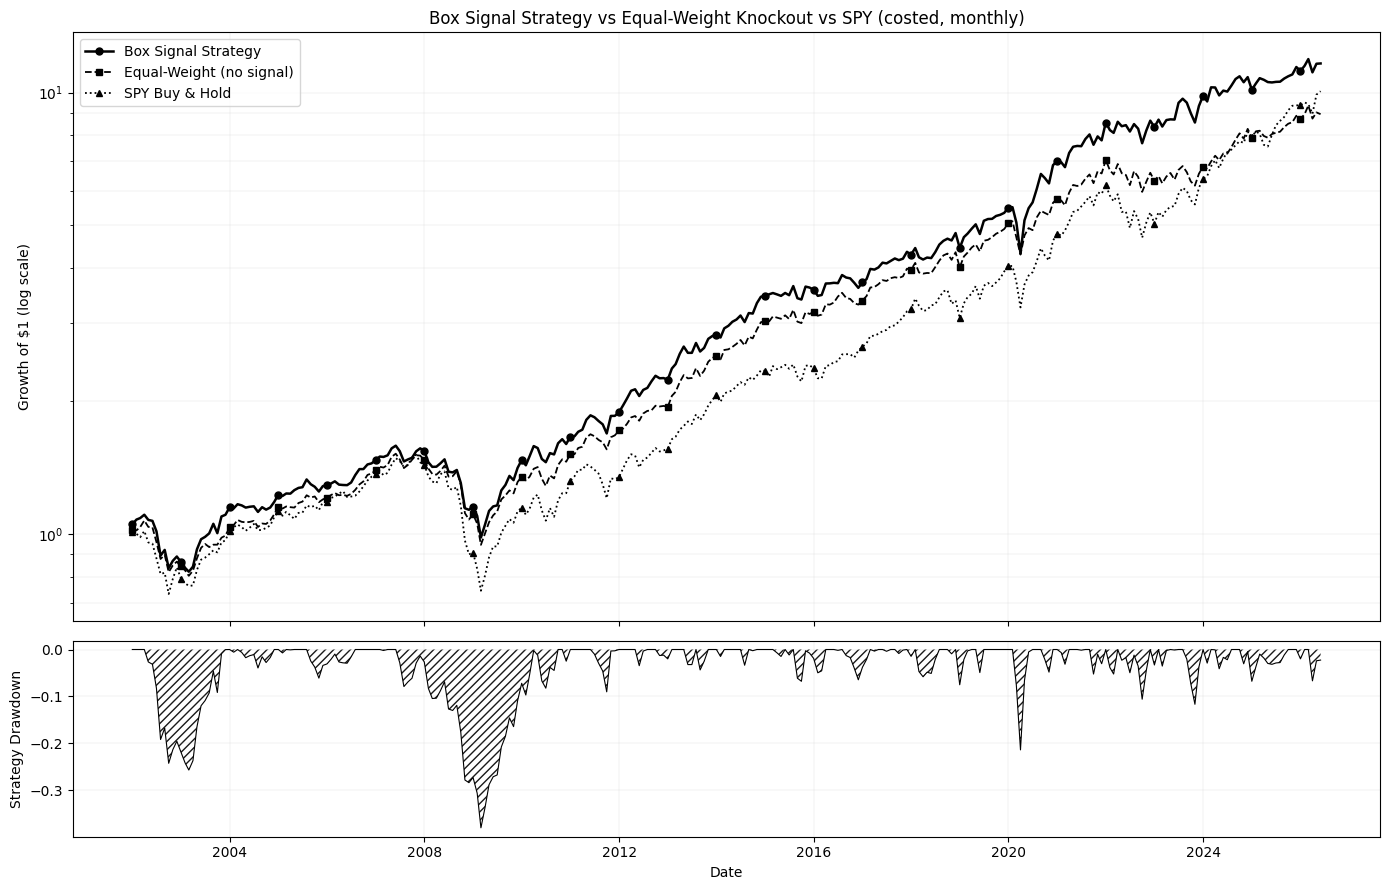

In [24]:
# =============================================================================
# 6.1 Equity curves and drawdown, grayscale-safe
# =============================================================================
# Rebuild the three monthly equity curves from the stored portfolio returns so
# we can draw them together. The harness scores on monthly returns, so we use
# the same monthly basis here for consistency with the metric tables above.

from vectorbt_harness import to_monthly

# Strategy (after costs), equal-weight knockout (after costs), and SPY, all monthly.
strat_daily = result.pf_costs.returns()
eq_daily = result_eq.pf_costs.returns()
bench_daily = result.bench_returns

# Common dates so all three curves start together.
common = strat_daily.index.intersection(bench_daily.index).intersection(eq_daily.index)

strat_curve = (1 + to_monthly(strat_daily.loc[common])).cumprod()
eq_curve = (1 + to_monthly(eq_daily.loc[common])).cumprod()
bench_curve = (1 + to_monthly(bench_daily.loc[common])).cumprod()

# Strategy drawdown from its own running peak.
strat_dd = strat_curve / strat_curve.cummax() - 1

# --- Plot: equity on top, drawdown below -----------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},
)

# Grayscale-safe: vary line style and marker shape, not color. Markers are
# sparse (every 12th month) so the lines stay readable.
ax1.plot(strat_curve.index, strat_curve.values,
         color='black', linestyle='-', linewidth=1.8,
         marker='o', markevery=12, markersize=5, label='Box Signal Strategy')
ax1.plot(eq_curve.index, eq_curve.values,
         color='black', linestyle='--', linewidth=1.3,
         marker='s', markevery=12, markersize=5, label='Equal-Weight (no signal)')
ax1.plot(bench_curve.index, bench_curve.values,
         color='black', linestyle=':', linewidth=1.3,
         marker='^', markevery=12, markersize=5, label='SPY Buy & Hold')

ax1.set_ylabel('Growth of $1 (log scale)')
ax1.set_yscale('log')   # log scale so early and late growth are both readable
ax1.set_title('Box Signal Strategy vs Equal-Weight Knockout vs SPY (after costs, monthly)')
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, which='both', linestyle='-', linewidth=0.3, alpha=0.4)

# Drawdown as shaded area with a hatch, so it survives grayscale printing.
ax2.fill_between(strat_dd.index, strat_dd.values, 0,
                 facecolor='none', edgecolor='black',
                 hatch='////', linewidth=0.0, alpha=0.9)
ax2.plot(strat_dd.index, strat_dd.values, color='black', linewidth=0.8)
ax2.set_ylabel('Strategy Drawdown')
ax2.set_xlabel('Date')
ax2.grid(True, linestyle='-', linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.show()

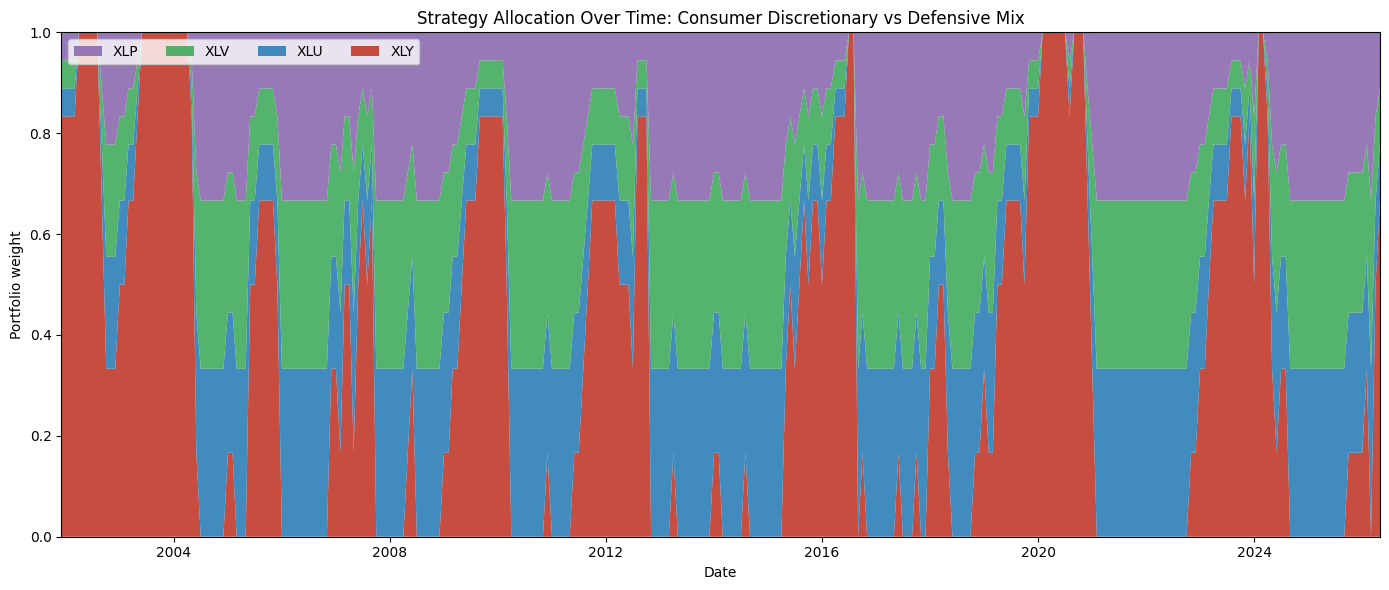

In [26]:
# =============================================================================
# 6.2 Strategy allocation over time
# =============================================================================
# Show the monthly weight in each of the four sectors as a stacked area. The
# stack always sums to 1.0 (fully invested). Consumer Discretionary is the
# offensive tilt; the three defensives sit on top of it. This chart is for
# screen viewing, so it uses color rather than the grayscale print styling.

alloc = weights[ALL_TICKERS].copy()

# One clear color per sector. XLY (offensive) in a strong color, the three
# defensives in cooler tones so the offensive/defensive split reads at a glance.
colors = {
    'XLY': '#c0392b',   # offensive: red
    'XLU': '#2c7fb8',   # defensive: blue
    'XLV': '#41ab5d',   # defensive: green
    'XLP': '#8c6bb1',   # defensive: purple
}

fig, ax = plt.subplots(figsize=(14, 6))

ax.stackplot(
    alloc.index,
    [alloc[t].values for t in ALL_TICKERS],
    labels=ALL_TICKERS,
    colors=[colors[t] for t in ALL_TICKERS],
    alpha=0.9,
)

ax.set_ylim(0, 1)
ax.set_xlim(alloc.index.min(), alloc.index.max())
ax.set_ylabel('Portfolio weight')
ax.set_xlabel('Date')
ax.set_title('Strategy Allocation Over Time: Consumer Discretionary vs Defensive Mix')

# Legend ordered top-of-stack first so it matches the visual band order.
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='upper left', frameon=True, ncol=4)

plt.tight_layout()
plt.show()

The equity chart shows where the strategy's edge actually comes from. For most of the run the three curves climb together, but the strategy separates from the pack at two specific moments, 2008 and 2020, and never gives the lead back. That timing is the whole point: the gap opens during crashes, not during calm markets, which is the signature of a strategy that wins by losing less. The drawdown panel underneath confirms it. The worst trough is 2008 at about 34 percent, and the 2020 plunge is steep but over quickly, both well short of the roughly 51 percent SPY gave up over the same window.

The allocation chart shows the mechanism behind that timing. The red band is the offensive share in Consumer Discretionary; the bands above it are the defensive mix. Two features stand out. First, the strategy is defensive far more often than not, with the red band low through most of the history. Second, the offensive spikes are not scattered randomly, they cluster at the bottoms, in 2003, 2009, and 2020, when the box PPI had fallen below its moving averages across most windows. The strategy was leaning hardest into the aggressive sector right as the market turned up from its lows, which is where the extra return in the knockout test came from. The graded structure is visible too: the red band climbs and falls in steps rather than flipping, because the offensive share is a count of bullish windows, not a single switch.

## 7.0 Summary

This notebook built a sector rotation strategy from an unusual signal, the producer price index for corrugated box manufacturing, and tested whether that signal carried real information. Along the way it worked through a problem that does not arise with price-based strategies: economic data gets revised after publication, so a careful backtest has to use the numbers that were actually available at the time, not the polished values we see today.

What we did:

- Pulled the box PPI two ways, the latest revised series and the first-release series from ALFRED, and measured the gap. Revisions happened in about four months out of ten, but they were tiny, averaging two-hundredths of a percent, far too small to flip the strategy's signal. We built on the first-release series anyway, because the discipline of using point-in-time data matters even when this particular series turns out forgiving.
- Built a graded signal from six moving averages of the PPI, voting between Consumer Discretionary and a defensive sector mix, with the offensive share stepping through seven levels rather than a simple on or off.
- Took care with the timing. Because the PPI is published with a delay, each month's trade acts on the prior month's data, dated so the strategy never uses a number before it existed. This is why the rebalance dates differ from the price-based strategies elsewhere in the chapter.
- Ran the strategy through the backtest harness with realistic costs, and tested it two ways: against SPY, and against an equal-weight knockout holding the same four sectors with no signal.

What we found:

- With costs applied, the strategy returned 10.54 percent a year against SPY's 9.89 percent, with a much shallower worst drawdown, 38 percent against 51, and better Sharpe, Sortino, and Calmar ratios. It beat the market on return while taking less risk, an uncommon combination.
- The knockout test settled whether the signal did real work. The same four sectors held statically returned only 9.35 percent and did not beat SPY. The signal added about 1.2 points of annual return on top of that, which is what carried the strategy past the market. The canary earned its place.
- One qualification stands out: the static basket ran at lower volatility, so on plain volatility-scaled return the two were a near tie. The strategy's edge shows up specifically on the downside-focused measures and on total return, the price of tilting hard into one sector when the signal turns offensive.

The wider lesson reaches past this one strategy. An alternative signal, drawn from somewhere the rest of the market is not looking, can carry information that price-based indicators miss, but it brings its own problems, and revision-driven lookahead bias is the one this notebook was built to handle. The method for catching it, pull the first-release series, measure the gap, and decide with the numbers in front of you, applies to any strategy built on revised economic data, whether or not the revisions turn out to matter as little as they did here.